<a href="https://colab.research.google.com/github/stnguswnd/LLM_Agent_Colab/blob/main/260601_langgraph_multi_agent_collaboration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Multi-agent Collaboration 기초예제
## 작성자 : AISchool ( http://aischool.ai/%ec%98%a8%eb%9d%bc%ec%9d%b8-%ea%b0%95%ec%9d%98-%ec%b9%b4%ed%85%8c%ea%b3%a0%eb%a6%ac/ )
## Reference : https://langchain-ai.github.io/langgraph/tutorials/multi_agent/multi-agent-collaboration/

하나의 에이전트는 일반적으로 단일 도메인 내에서 소수의 도구만으로도 효과적으로 작동할 수 있습니다. 그러나 GPT-4와 같은 강력한 모델을 사용하더라도 많은 도구를 사용할 때는 덜 효과적일 수 있습니다.

복잡한 작업에 접근하는 한 가지 방법은 **"분할 정복"(divide-and-conquer) 접근법**입니다. **각 작업이나 도메인에 특화된 에이전트를 생성하고 작업을 올바른 "전문가"에게 라우팅**하는 방식입니다.

이 예제는 Wu 외 연구진이 작성한 논문 AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation ( https://arxiv.org/abs/2308.08155 )에서 영감을 받아 이를 LangGraph를 사용하여 구현하는 방법을 보여줍니다.

결과 그래프는 다음 다이어그램과 유사한 형태가 될 것입니다.









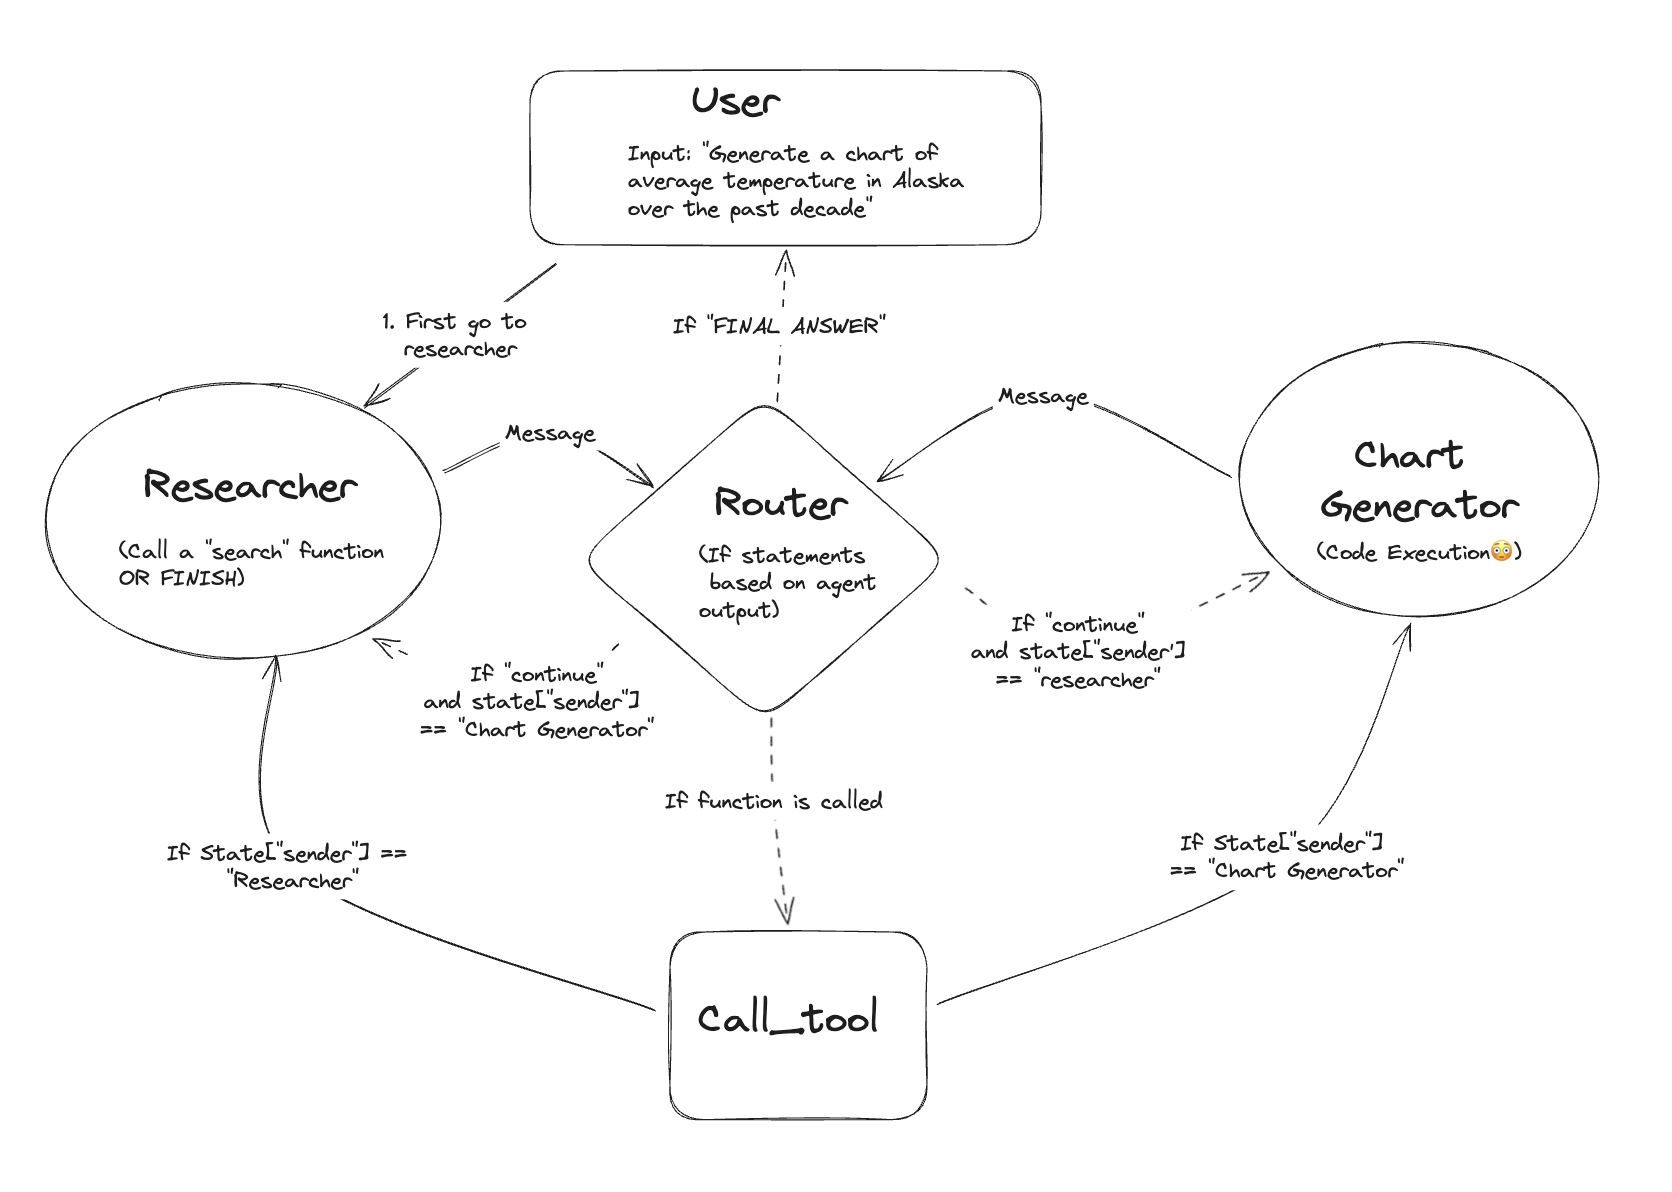

시작하기 전에 간단한 주의 사항입니다: 이 노트북과 다른 다중 에이전트 노트북들은 LangGraph에서 특정 디자인 패턴을 구현하는 방법을 보여주기 위해 설계되었습니다. 이 패턴이 귀하의 필요에 맞는다면, 최상의 성능을 위해 문서의 다른 기본 패턴들과 결합하여 사용하는 것을 권장합니다.









# 라이브러리 설치

In [1]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


# API Key 설정

In [2]:
import os
from uuid import uuid4

unique_id = uuid4().hex[0:8]
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"Basic Multi-agent Collaboration - {unique_id}"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

from google.colab import userdata
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")

In [ ]:
unique_id

'474ee257'

# Create Agents


다음 보조 함수들은 에이전트를 생성하는 데 도움을 줄 것입니다. 이러한 에이전트들은 그래프의 노드가 됩니다.

그래프가 어떻게 생겼는지 바로 보고 싶다면 이 부분을 건너뛰어도 됩니다.

In [3]:
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import END, StateGraph, START


def create_agent(llm, tools, system_message: str):
    """Create an agent."""
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_tools(tools)

In [ ]:
# "당신은 다른 AI 어시스턴트들과 협력하는 유용한 AI 어시스턴트입니다."
# "질문에 답을 진행하기 위해 제공된 도구들을 사용하세요."
# "만약 질문에 완전히 답하지 못하더라도 괜찮습니다. 다른 도구를 가진 또 다른 어시스턴트가"
# "당신이 멈춘 부분을 도울 것입니다. 할 수 있는 만큼 실행하여 진전을 이루세요."
# "만약 당신이나 다른 어시스턴트가 최종 답변이나 결과물을 가지고 있다면,"
# "응답의 시작에 'FINAL ANSWER'라고 표기하여 팀이 멈추도록 하세요."
# "당신은 다음 도구들에 접근할 수 있습니다: {tool_names}.\n{system_message}"

# Define tools


또한 나중에 에이전트들이 사용할 몇 가지 도구도 정의할 것입니다.


In [4]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

/tmp/ipykernel_1888/834236089.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
/tmp/ipykernel_1888/834236089.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


In [ ]:
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

# Create graph


이제 도구들을 정의하고 보조 함수를 만들었으니, 아래에서 **개별 에이전트들을 생성하고 LangGraph를 사용하여 서로 소통하는 방법**을 알려주겠습니다.

## Define State


먼저 그래프의 상태를 정의합니다. 이는 단순히 메시지 목록과, 가장 최근에 메시지를 보낸 발신자(sender)를 추적하는 키로 구성됩니다.

In [ ]:
import operator
from typing import Annotated, Sequence, TypedDict

from langchain_openai import ChatOpenAI


# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

## Define Agent Nodes

이제 노드를 정의해야 합니다. 먼저, 에이전트들을 위한 노드를 정의하겠습니다.









In [ ]:
import functools

from langchain_core.messages import AIMessage


# Helper function to create a node for a given agent
def agent_node(state, agent, name):
    result = agent.invoke(state)
    # We convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, ToolMessage):
        pass
    else:
        result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        # Since we have a strict workflow, we can
        # track the sender so we know who to pass to next.
        "sender": name,
    }


llm = ChatOpenAI(model="gpt-4o")

## 검색을 이용하는 Research Agent 생성

In [ ]:
# Research agent and node
research_agent = create_agent(
    llm,
    [tavily_tool],
    system_message="You should provide accurate data for use, "
        "and source code shouldn't be the final answer",
)
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

## Python 코드 실행기를 사용하는 Chart Agent 생성

In [ ]:
# chart_generator
chart_agent = create_agent(
    llm,
    [python_repl],
    system_message="Run the python code to display the chart.",
)
chart_node = functools.partial(agent_node, agent=chart_agent, name="chart_generator")

# Define Tool Node


이제 도구들을 실행할 노드를 정의하겠습니다.









In [ ]:
from langgraph.prebuilt import ToolNode

tools = [tavily_tool, python_repl]
tool_node = ToolNode(tools)

# Define Edge Logic

이제 에이전트들의 결과에 따라 무엇을 할지 결정하는 데 필요한 일부 엣지 로직을 정의할 수 있습니다.









In [ ]:
# Either agent can decide to end
from typing import Literal


def router(state) -> Literal["call_tool", "__end__", "continue"]:
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        # The previous agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return "__end__"
    return "continue"

# Define the Graph

이제 모든 것을 합쳐서 그래프를 정의할 수 있습니다!









In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Researcher",
    router,
    {"continue": "chart_generator", "call_tool": "call_tool", "__end__": END},
)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "Researcher", "call_tool": "call_tool", "__end__": END},
)

workflow.add_conditional_edges(
    "call_tool",
    # Each agent node updates the 'sender' field
    # the tool calling node does not, meaning
    # this edge will route back to the original agent
    # who invoked the tool
    lambda x: x["sender"],
    {
        "Researcher": "Researcher",
        "chart_generator": "chart_generator",
    },
)
workflow.add_edge(START, "Researcher")
graph = workflow.compile()

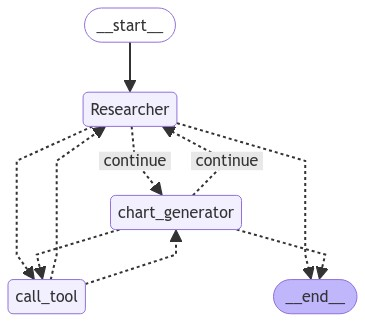

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


# Invoke

그래프가 생성되었으니 이제 실행할 수 있습니다! 몇 가지 통계를 차트로 표시해 보겠습니다.

{'Researcher': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_tgQqB9scUFFt0qe15eV4NrKQ', 'function': {'arguments': '{"query": "USA GDP 2022"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'call_G5ZyHbsjl06alktLmU6TGTB9', 'function': {'arguments': '{"query": "USA GDP 2021"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'call_vNf0CZyaLjgxhfkGAJMp3isW', 'function': {'arguments': '{"query": "USA GDP 2020"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 223, 'total_tokens': 305}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5', 'finish_reason': 'tool_calls', 'logprobs': None}, name='Researcher', id='run-155cc4ff-8583-4258-8577-541d92c2df05-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'USA GDP 2022'}, 'id': 'call_tgQqB9scUFFt0qe15eV4NrKQ', 'type': 't

{'chart_generator': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_T3MApY2Z99TN7xLtDh6ztVa1', 'function': {'arguments': '{"code":"import matplotlib.pyplot as plt\\n\\n# Data for the past 3 years\\nyears = [2020, 2021, 2022]\\ngdp_values = [21433.23, 23315.08, 25439.70]\\n\\n# Create the line plot\\nplt.figure(figsize=(10, 6))\\nplt.plot(years, gdp_values, marker=\'o\')\\n\\n# Adding titles and labels\\nplt.title(\'USA GDP Over the Past 3 Years\')\\nplt.xlabel(\'Year\')\\nplt.ylabel(\'GDP in Billions (USD)\')\\nplt.grid(True)\\n\\n# Show the plot\\nplt.show()\\n"}', 'name': 'python_repl'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 4803, 'total_tokens': 4960}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5', 'finish_reason': 'tool_calls', 'logprobs': None}, name='chart_generator', id='run-e39f22db-f360-40e1-b10c-1c83caae17b1-0', tool_calls=[{'name': 'py

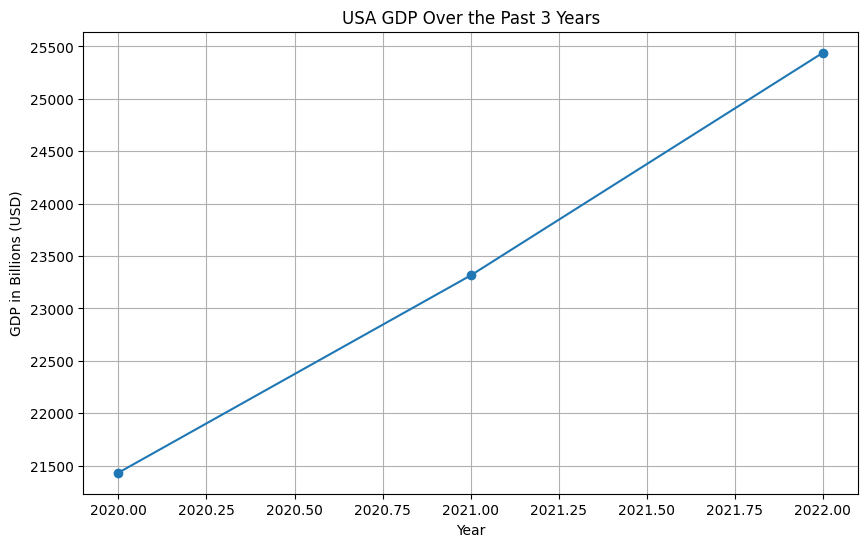

{'call_tool': {'messages': [ToolMessage(content="Successfully executed:\n```python\nimport matplotlib.pyplot as plt\n\n# Data for the past 3 years\nyears = [2020, 2021, 2022]\ngdp_values = [21433.23, 23315.08, 25439.70]\n\n# Create the line plot\nplt.figure(figsize=(10, 6))\nplt.plot(years, gdp_values, marker='o')\n\n# Adding titles and labels\nplt.title('USA GDP Over the Past 3 Years')\nplt.xlabel('Year')\nplt.ylabel('GDP in Billions (USD)')\nplt.grid(True)\n\n# Show the plot\nplt.show()\n\n```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.", name='python_repl', tool_call_id='call_T3MApY2Z99TN7xLtDh6ztVa1')]}}
----
{'chart_generator': {'messages': [AIMessage(content="Here is the line graph of the USA's GDP over the past 3 years:\n\n![USA GDP Over the Past 3 Years](sandbox:/mnt/data/plot.png)\n\nFINAL ANSWER", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 5121, 'total_tokens': 5160}, 'model_na

In [ ]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Fetch the USA's GDP over the past 3 years,"
                " then draw a line graph of it."
                " Once you code it up, finish."
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 10},
)
for s in events:
    print(s)
    print("----")